<a href="https://colab.research.google.com/github/RaghadAlbeladi1/SDAIA_Drug_Safety_Pipeline/blob/main/SDAIA_Drug_Safety_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving drug_side_effects_100k_dataset.csv to drug_side_effects_100k_dataset.csv


In [2]:
import os
print(os.path.exists("/content/drug_side_effects_100k_dataset.csv"))

True


## Step 1: Environment Setup
Install PySpark (data processing) and Delta Lake (reliable storage), then start a Spark session.

In [3]:
!pip install -q pyspark==3.5.3 delta-spark==3.2.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 14.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.3 which is incompatible.


In [4]:
from pyspark.sql import SparkSession
from delta import configure_spark_with_delta_pip

# Start Spark with Delta Lake support
builder = (SparkSession.builder.appName("SDAIA_Drug_Safety_Pipeline")
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension")
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog"))
spark = configure_spark_with_delta_pip(builder).getOrCreate()
print("Spark version:", spark.version)

Spark version: 3.5.3


## Step 2: Data Ingestion (Bronze Layer)
Batch ingestion of the CSV file using Spark with an enforced schema (first line of defense for data quality). Raw data is stored as-is in the Bronze Delta table.

In [5]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType

DATA_PATH = "/content/drug_side_effects_100k_dataset.csv"
BRONZE_PATH = "/content/lakehouse/bronze/drug_reports"

# Enforce schema instead of letting Spark guess column types
schema = StructType([
    StructField("patient_id", StringType()), StructField("age", IntegerType()),
    StructField("gender", StringType()), StructField("country", StringType()),
    StructField("drug_name", StringType()), StructField("dosage_mg", IntegerType()),
    StructField("side_effect", StringType()), StructField("severity", StringType()),
    StructField("outcome", StringType()), StructField("report_date", StringType()),
    StructField("treatment_start_date", StringType()), StructField("chronic_condition", StringType()),
    StructField("smoker", StringType()), StructField("alcohol_use", StringType()),
    StructField("hospitalized", StringType()), StructField("recovery_days", DoubleType()),
])

raw_df = spark.read.csv(DATA_PATH, header=True, schema=schema)
print("Rows ingested:", raw_df.count())
raw_df.show(5)

# Save raw data to Bronze layer (Delta format)
raw_df.write.format("delta").mode("overwrite").save(BRONZE_PATH)
print("Saved to Bronze layer ✅")

Rows ingested: 100000
+----------+---+------+--------+------------+---------+------------+--------+----------+-----------+--------------------+-----------------+------+-----------+------------+-------------+
|patient_id|age|gender| country|   drug_name|dosage_mg| side_effect|severity|   outcome|report_date|treatment_start_date|chronic_condition|smoker|alcohol_use|hospitalized|recovery_days|
+----------+---+------+--------+------------+---------+------------+--------+----------+-----------+--------------------+-----------------+------+-----------+------------+-------------+
| PT-100000| 56|Female|     USA|Atorvastatin|       25| Muscle Pain|Moderate|Recovering| 2021-12-08|          2021-11-23|     Hypertension|   Yes|   Frequent|          No|         36.0|
| PT-100001| 45|  Male|     USA|  Sertraline|        5|   Dry Mouth|    Mild| Recovered| 2023-02-10|          2023-02-04|     Hypertension|   Yes|   Frequent|          No|         40.0|
| PT-100002| 76|Female|Pakistan|     Insulin|   

## Step 3: Transformation (Raw → Clean)
Select the 8 relevant columns, trim extra spaces, standardize text casing, and add an ingestion timestamp.

In [6]:
from pyspark.sql import functions as F

COLUMNS = ["patient_id", "age", "gender", "drug_name", "dosage_mg", "side_effect", "severity", "outcome"]

def transform(df):
    df = df.select(COLUMNS)                                   # keep relevant columns only
    df = df.withColumn("patient_id", F.trim("patient_id"))    # remove extra spaces
    for c in ["gender", "drug_name", "side_effect", "severity", "outcome"]:
        df = df.withColumn(c, F.initcap(F.trim(F.col(c))))    # trim + standardize casing
    return df.withColumn("ingested_at", F.current_timestamp())

clean_df = transform(raw_df)
print("Columns after transformation:", clean_df.columns)
clean_df.show(5)

Columns after transformation: ['patient_id', 'age', 'gender', 'drug_name', 'dosage_mg', 'side_effect', 'severity', 'outcome', 'ingested_at']
+----------+---+------+------------+---------+------------+--------+----------+--------------------+
|patient_id|age|gender|   drug_name|dosage_mg| side_effect|severity|   outcome|         ingested_at|
+----------+---+------+------------+---------+------------+--------+----------+--------------------+
| PT-100000| 56|Female|Atorvastatin|       25| Muscle Pain|Moderate|Recovering|2026-10-01 06:31:...|
| PT-100001| 45|  Male|  Sertraline|        5|   Dry Mouth|    Mild| Recovered|2026-10-01 06:31:...|
| PT-100002| 76|Female|     Insulin|       25|Hypoglycemia|    Mild|Recovering|2026-10-01 06:31:...|
| PT-100003| 61|Female| Paracetamol|       20|        Rash|Moderate| Recovered|2026-10-01 06:31:...|
| PT-100004| 39|Female|  Amlodipine|        5|   Dizziness|    Mild| Recovered|2026-10-01 06:31:...|
+----------+---+------+------------+---------+-----

## Step 4: Data Quality Checks
Four checks from the course. All rules are defined in one place (RULES) so they are easy to change.
- **Completeness:** patient_id, drug_name, side_effect, severity must not be empty
- **Uniqueness:** patient_id must not repeat
- **Validity:** age between 0–120, gender and severity from allowed values
- **Accuracy / Business Rule:** dosage_mg must be greater than 0

In [7]:
RULES = {
    "required_columns": ["patient_id", "drug_name", "side_effect", "severity"],
    "age_range": (0, 120),
    "valid_gender": ["Male", "Female"],
    "valid_severity": ["Mild", "Moderate", "Severe"],
    "max_error_rate": 0.05,   # Quality Gate threshold: max 5% errors per check
}

def run_quality_checks(df):
    total = df.count()

    # 1) Completeness: required fields must not be null or empty
    missing = F.lit(False)
    for c in RULES["required_columns"]:
        missing = missing | F.col(c).isNull() | (F.trim(F.col(c)) == "")
    incomplete = df.filter(missing).count()

    # 2) Uniqueness: patient_id must not repeat
    duplicates = total - df.select("patient_id").distinct().count()

    # 3) Validity: age range + allowed values for gender and severity
    lo, hi = RULES["age_range"]
    is_valid = (F.col("age").between(lo, hi)
                & F.col("gender").isin(RULES["valid_gender"])
                & F.col("severity").isin(RULES["valid_severity"]))
    invalid = df.filter(~F.coalesce(is_valid, F.lit(False))).count()

    # 4) Accuracy / Business rule: dosage must be positive
    bad_dosage = df.filter(~F.coalesce(F.col("dosage_mg") > 0, F.lit(False))).count()

    failures = {"Completeness": incomplete, "Uniqueness": duplicates,
                "Validity": invalid, "Accuracy (dosage > 0)": bad_dosage}
    return total, {name: (n, n / total) for name, n in failures.items()}

total, report = run_quality_checks(clean_df)
print(f"Total rows: {total:,}\n")
for name, (n, rate) in report.items():
    print(f"{name:<24} failed rows: {n:>6,}   error rate: {rate:.2%}")

Total rows: 100,000

Completeness             failed rows:      0   error rate: 0.00%
Uniqueness               failed rows:      0   error rate: 0.00%
Validity                 failed rows:      0   error rate: 0.00%
Accuracy (dosage > 0)    failed rows:      0   error rate: 0.00%


## Step 5: Quality Gate (PASS / FAIL)
If every check has an error rate ≤ 5% → **PASS** → data is saved to the Silver layer (Delta Lake, trusted data).
Otherwise → **FAIL** → the whole batch is sent to **Quarantine** with the reason.

In [8]:
SILVER_PATH = "/content/lakehouse/silver/drug_reports"
QUARANTINE_PATH = "/content/lakehouse/quarantine/drug_reports"

def quality_gate(df, batch_id):
    total, report = run_quality_checks(df)
    failed = [name for name, (n, rate) in report.items() if rate > RULES["max_error_rate"]]

    print(f"===== Quality Gate: {batch_id} ({total:,} rows) =====")
    for name, (n, rate) in report.items():
        print(f"{'❌' if name in failed else '✅'} {name:<24} {rate:.2%}")

    if not failed:
        # PASS → trusted data goes to Silver (Delta Lake)
        (df.withColumn("batch_id", F.lit(batch_id))
           .write.format("delta").mode("overwrite").save(SILVER_PATH))
        print("RESULT: PASS ✅ → saved to Silver (Delta Lake)")
        return "PASS"
    else:
        # FAIL → whole batch goes to Quarantine with the reason
        (df.withColumn("batch_id", F.lit(batch_id))
           .withColumn("failed_checks", F.lit(", ".join(failed)))
           .withColumn("quarantined_at", F.current_timestamp())
           .write.format("delta").mode("append").save(QUARANTINE_PATH))
        print(f"RESULT: FAIL ❌ → sent to Quarantine. Failed checks: {', '.join(failed)}")
        return "FAIL"

# PASS case: the original dataset
quality_gate(clean_df, "batch_001_original")

===== Quality Gate: batch_001_original (100,000 rows) =====
✅ Completeness             0.00%
✅ Uniqueness               0.00%
✅ Validity                 0.00%
✅ Accuracy (dosage > 0)    0.00%
RESULT: PASS ✅ → saved to Silver (Delta Lake)


'PASS'

## Step 6: Failing Case Demo
To prove the gate works, we create a corrupted batch from our data: invalid ages (-5), missing drug names, negative dosages, and 300 duplicated patient IDs.

In [9]:
# Build a corrupted batch of 2,300 rows to test the gate
sample = clean_df.orderBy("patient_id").limit(2000)
bucket = F.abs(F.hash("patient_id")) % 10          # pick ~10% of rows for each error type

bad_df = (sample
    .withColumn("age", F.when(bucket == 1, F.lit(-5)).otherwise(F.col("age")))                  # invalid age
    .withColumn("drug_name", F.when(bucket == 2, F.lit(None)).otherwise(F.col("drug_name")))    # missing drug
    .withColumn("dosage_mg", F.when(bucket == 3, F.lit(-50)).otherwise(F.col("dosage_mg")))     # negative dosage
    .unionByName(sample.limit(300)))                                                            # duplicates
bad_df.cache()

# FAIL case
quality_gate(bad_df, "batch_002_corrupted")

===== Quality Gate: batch_002_corrupted (2,300 rows) =====
❌ Completeness             8.83%
❌ Uniqueness               13.04%
❌ Validity                 9.30%
❌ Accuracy (dosage > 0)    8.83%
RESULT: FAIL ❌ → sent to Quarantine. Failed checks: Completeness, Uniqueness, Validity, Accuracy (dosage > 0)


'FAIL'

## Step 7: Analytics (Gold Layer)
Business-ready tables built **only from trusted Silver data**:
1. Severe side-effect rate and hospitalization/fatality rate per drug
2. Top 3 most common side effects per drug

In [10]:
GOLD_PATH = "/content/lakehouse/gold"
silver = spark.read.format("delta").load(SILVER_PATH)   # read trusted data only

# Gold table 1: safety summary per drug
drug_safety = (silver.groupBy("drug_name")
    .agg(F.count("*").alias("total_reports"),
         F.sum(F.when(F.col("severity") == "Severe", 1).otherwise(0)).alias("severe_cases"),
         F.sum(F.when(F.col("outcome").isin("Hospitalized", "Fatal"), 1).otherwise(0)).alias("hospitalized_or_fatal"))
    .withColumn("severe_pct", F.round(F.col("severe_cases") / F.col("total_reports") * 100, 2))
    .withColumn("hospitalized_or_fatal_pct", F.round(F.col("hospitalized_or_fatal") / F.col("total_reports") * 100, 2))
    .orderBy(F.desc("severe_pct")))

drug_safety.write.format("delta").mode("overwrite").save(f"{GOLD_PATH}/drug_safety_summary")
drug_safety.show()

+------------+-------------+------------+---------------------+----------+-------------------------+
|   drug_name|total_reports|severe_cases|hospitalized_or_fatal|severe_pct|hospitalized_or_fatal_pct|
+------------+-------------+------------+---------------------+----------+-------------------------+
| Amoxicillin|        10148|         867|                 1195|      8.54|                    11.78|
|Atorvastatin|        10035|         839|                 1207|      8.36|                    12.03|
|  Lisinopril|         9814|         819|                 1199|      8.35|                    12.22|
| Paracetamol|         9957|         822|                 1188|      8.26|                    11.93|
|  Sertraline|        10018|         816|                 1173|      8.15|                    11.71|
|   Metformin|        10078|         818|                 1163|      8.12|                    11.54|
|     Insulin|         9940|         800|                 1137|      8.05|                 

In [11]:
from pyspark.sql.window import Window

# Gold table 2: top 3 side effects per drug
w = Window.partitionBy("drug_name").orderBy(F.desc("reports"), "side_effect")
top_effects = (silver.groupBy("drug_name", "side_effect").agg(F.count("*").alias("reports"))
    .withColumn("rank", F.row_number().over(w))
    .filter(F.col("rank") <= 3)
    .orderBy("drug_name", "rank"))

top_effects.write.format("delta").mode("overwrite").save(f"{GOLD_PATH}/top_side_effects")
top_effects.show(30)

+------------+--------------+-------+----+
|   drug_name|   side_effect|reports|rank|
+------------+--------------+-------+----+
|  Amlodipine|     Dizziness|   3396|   1|
|  Amlodipine|      Swelling|   3340|   2|
|  Amlodipine|  Palpitations|   3284|   3|
| Amoxicillin|        Nausea|   3410|   1|
| Amoxicillin|          Rash|   3392|   2|
| Amoxicillin|      Diarrhea|   3346|   3|
|Atorvastatin|       Fatigue|   3389|   1|
|Atorvastatin|   Muscle Pain|   3358|   2|
|Atorvastatin|      Headache|   3288|   3|
|   Ibuprofen|        Nausea|   3348|   1|
|   Ibuprofen|  Stomach Pain|   3348|   2|
|   Ibuprofen|     Heartburn|   3319|   3|
|     Insulin|      Sweating|   3358|   1|
|     Insulin|   Weight Gain|   3329|   2|
|     Insulin|  Hypoglycemia|   3253|   3|
|  Lisinopril|     Dizziness|   3283|   1|
|  Lisinopril|     Dry Cough|   3275|   2|
|  Lisinopril|       Fatigue|   3256|   3|
|   Metformin|Abdominal Pain|   3414|   1|
|   Metformin|      Diarrhea|   3339|   2|
|   Metform

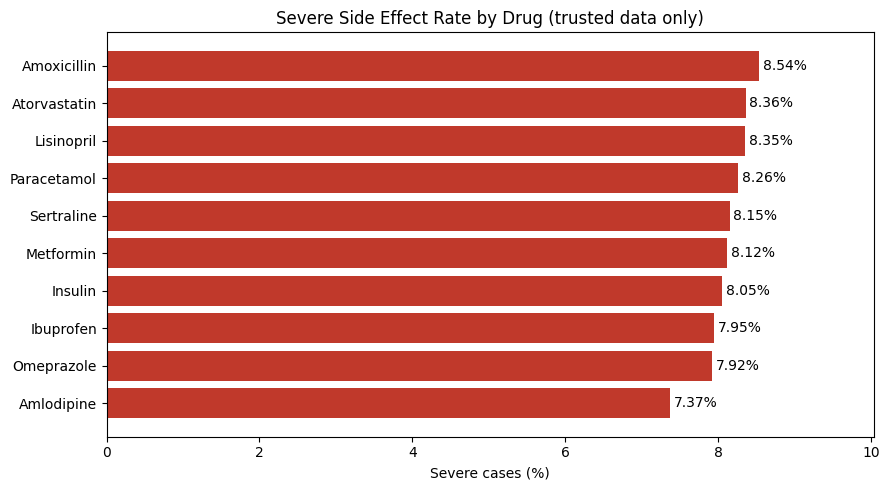

In [12]:
import matplotlib.pyplot as plt

pdf = drug_safety.toPandas().sort_values("severe_pct")
plt.figure(figsize=(9, 5))
plt.barh(pdf["drug_name"], pdf["severe_pct"], color="#c0392b")
plt.xlabel("Severe cases (%)")
plt.title("Severe Side Effect Rate by Drug (trusted data only)")
for i, v in enumerate(pdf["severe_pct"]):
    plt.text(v + 0.05, i, f"{v}%", va="center")
plt.xlim(0, pdf["severe_pct"].max() + 1.5)
plt.tight_layout()
plt.show()

## Step 8: RAG Assistant (Trusted Data Only)
1. **Documents / Chunks:** each Gold row becomes one text chunk (one per drug + one comparison chunk)
2. **Embeddings:** chunks converted to vectors with `all-MiniLM-L6-v2`
3. **Vector DB + Retrieval:** vectors stored in FAISS; the 2 closest chunks are retrieved for each question
4. **LLM:** `Qwen2.5-0.5B-Instruct` answers using ONLY the retrieved context

In [13]:
!pip install -q faiss-cpu sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 24.7 MB/s eta 0:00:00


In [17]:
# Read Gold tables (trusted data)
safety = spark.read.format("delta").load(f"{GOLD_PATH}/drug_safety_summary").toPandas()
effects = spark.read.format("delta").load(f"{GOLD_PATH}/top_side_effects").toPandas()

# Each drug becomes one text chunk
documents = []
for r in safety.itertuples():
    top3 = effects[effects.drug_name == r.drug_name].sort_values("rank")
    top3_text = ", ".join(f"{e.side_effect} ({e.reports:,} reports)" for e in top3.itertuples())
    documents.append(
        f"{r.drug_name}: {r.total_reports:,} side-effect reports. "
        f"Most common side effects: {top3_text}. "
        f"Severe cases: {r.severe_cases:,} ({r.severe_pct}%). "
        f"Hospitalized or fatal: {r.hospitalized_or_fatal:,} ({r.hospitalized_or_fatal_pct}%).")

# One extra chunk to answer comparison questions (highest/lowest stated explicitly)
ranked = safety.sort_values("severe_pct", ascending=False)
top, low = ranked.iloc[0], ranked.iloc[-1]
documents.append(
    f"Drug comparison: the drug with the HIGHEST severe side-effect rate is {top.drug_name} ({top.severe_pct}%). "
    f"The drug with the LOWEST severe side-effect rate is {low.drug_name} ({low.severe_pct}%). "
    "Full ranking from highest to lowest: "
    + ", ".join(f"{r.drug_name} {r.severe_pct}%" for r in ranked.itertuples()) + ".")

print("Number of chunks:", len(documents))
print("\nExample chunk:\n", documents[0])

Number of chunks: 11

Example chunk:
 Amoxicillin: 10,148 side-effect reports. Most common side effects: Nausea (3,410 reports), Rash (3,392 reports), Diarrhea (3,346 reports). Severe cases: 867 (8.54%). Hospitalized or fatal: 1,195 (11.78%).


In [18]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

# Convert chunks to vectors (embeddings)
embedder = SentenceTransformer("all-MiniLM-L6-v2")
doc_vectors = embedder.encode(documents, normalize_embeddings=True)

# Store vectors in FAISS (vector database)
index = faiss.IndexFlatIP(doc_vectors.shape[1])
index.add(np.array(doc_vectors, dtype="float32"))
print("Vectors stored in FAISS:", index.ntotal)

# Retrieval: find the closest chunks to a question
def retrieve(question, k=2):
    q = embedder.encode([question], normalize_embeddings=True)
    scores, ids = index.search(np.array(q, dtype="float32"), k)
    return [documents[i] for i in ids[0]]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Vectors stored in FAISS: 11


In [19]:
import transformers; transformers.logging.set_verbosity_error()   # hide warnings
from transformers import pipeline

llm = pipeline("text-generation", model="Qwen/Qwen2.5-0.5B-Instruct")

def ask(question):
    context = "\n".join(retrieve(question))
    messages = [
        {"role": "system", "content": "You are a drug safety assistant. Answer ONLY using the context. "
                                      "If the answer is not in the context, say you don't know. Keep it short."},
        {"role": "user", "content": f"Context:\n{context}\n\nQuestion: {question}"},
    ]
    answer = llm(messages, max_new_tokens=120, do_sample=False)[0]["generated_text"][-1]["content"]
    print("❓ Question:", question)
    print("📄 Retrieved context:\n" + context)
    print("🤖 Answer:", answer, "\n" + "-" * 80)

ask("What are the most common side effects of Insulin?")
ask("Which drug has the highest rate of severe side effects?")
ask("How many Paracetamol cases ended in hospitalization or death?")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

❓ Question: What are the most common side effects of Insulin?
📄 Retrieved context:
Insulin: 9,940 side-effect reports. Most common side effects: Sweating (3,358 reports), Weight Gain (3,329 reports), Hypoglycemia (3,253 reports). Severe cases: 800 (8.05%). Hospitalized or fatal: 1,137 (11.44%).
Metformin: 10,078 side-effect reports. Most common side effects: Abdominal Pain (3,414 reports), Diarrhea (3,339 reports), Nausea (3,325 reports). Severe cases: 818 (8.12%). Hospitalized or fatal: 1,163 (11.54%).
🤖 Answer: The most common side effects of insulin are sweating and weight gain. 
--------------------------------------------------------------------------------
❓ Question: Which drug has the highest rate of severe side effects?
📄 Retrieved context:
Drug comparison: the drug with the HIGHEST severe side-effect rate is Amoxicillin (8.54%). The drug with the LOWEST severe side-effect rate is Amlodipine (7.37%). Full ranking from highest to lowest: Amoxicillin 8.54%, Atorvastatin 8.36%, L